<div style="
    width:100%;
    box-sizing:border-box;
    background:
        radial-gradient(circle at 92% 8%,rgba(16,185,129,0.10),transparent 25%),
        radial-gradient(circle at 8% 92%,rgba(20,184,166,0.07),transparent 28%),
        linear-gradient(135deg,#F4FBF8 0%,#FFFFFF 48%,#EFFAF6 100%);
    padding:30px 36px;
    border-radius:26px;
    font-family:'Segoe UI',Arial,sans-serif;
    border:1px solid #A8D2C3;
    box-shadow:0 12px 32px rgba(6,78,59,0.10);
">

<div style="
    display:flex;
    align-items:center;
    gap:14px;
">

<div style="
    width:46px;
    height:46px;
    border-radius:14px;
    background:#E1F4EC;
    border:1px solid #A8D2C3;
    display:flex;
    align-items:center;
    justify-content:center;
    color:#047857;
    font-size:19px;
    font-weight:900;
">
🧪
</div>

<div>

<div style="
    color:#0B2923;
    font-size:25px;
    font-weight:900;
    line-height:1.2;
">
Hands-On Lab: Training a Neural Network
</div>

<div style="
    color:#115E59;
    font-size:9px;
    font-weight:900;
    letter-spacing:2px;
    margin-top:6px;
">
WEEK 6 • DAY 3 • TRAINING + MODEL REVIEW
</div>

</div>

</div>

<div style="
    margin-top:19px;
    padding:13px 17px;
    background:#F1F9F6;
    border:1px solid #C1DED2;
    border-left:4px solid #10B981;
    border-radius:13px;
    color:#475569;
    font-size:11px;
    line-height:1.7;
    font-weight:600;
">
In this lab, we will build, train, evaluate, and improve a neural network for the cardiac disease classification task.
</div>

</div>

<div style="
    width:100%;
    box-sizing:border-box;
    background:#F7FCFA;
    padding:20px 24px;
    border-radius:19px;
    font-family:'Segoe UI',Arial,sans-serif;
    border:1px solid #B8DACE;
    border-left:5px solid #10B981;
">

<div style="
    color:#047857;
    font-size:9px;
    font-weight:900;
    letter-spacing:1.8px;
">
SETUP • DATA PREPARATION
</div>

<div style="
    color:#0B2923;
    font-size:20px;
    font-weight:900;
    margin-top:5px;
">
Prepare the Training and Test Data
</div>

<div style="
    color:#52665F;
    font-size:11px;
    line-height:1.7;
    margin-top:7px;
">
Load the cardiac dataset, separate the features from the target, and create stratified training and test sets for the neural network.
</div>

</div>

In [4]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import tensorflow as tf

print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("TensorFlow:", tf.__version__)

Pandas: 3.0.5
Scikit-learn: 1.9.0
TensorFlow: 2.21.0


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("..\input\heart_disease_uci.csv", sep=";")

X = df.drop(columns=["cardio"])
y = df["cardio"]

X = X.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Dataset shape:", df.shape)
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Target classes:", sorted(y.unique()))

<>:6: SyntaxWarning: invalid escape sequence '\i'
<>:6: SyntaxWarning: invalid escape sequence '\i'
C:\Users\lenovo\AppData\Local\Temp\ipykernel_13880\976825711.py:6: SyntaxWarning: invalid escape sequence '\i'
  df = pd.read_csv("..\input\heart_disease_uci.csv", sep=";")


Dataset shape: (70000, 13)
Training shape: (56000, 12)
Test shape: (14000, 12)
Target classes: [np.int64(0), np.int64(1)]


<div style="
    width:100%;
    box-sizing:border-box;
    background:#F7FCFA;
    padding:20px 24px;
    border-radius:19px;
    font-family:'Segoe UI',Arial,sans-serif;
    border:1px solid #B8DACE;
    border-left:5px solid #10B981;
">

<div style="
    color:#047857;
    font-size:9px;
    font-weight:900;
    letter-spacing:1.8px;
">
STEP 01
</div>

<div style="
    color:#0B2923;
    font-size:20px;
    font-weight:900;
    margin-top:5px;
">
Build the Keras Sequential Network
</div>

<div style="
    color:#52665F;
    font-size:11px;
    line-height:1.7;
    margin-top:7px;
">
Build a neural network suitable for the cardiac classification task.
The output layer must match the five target classes, using softmax for multi-class prediction.
</div>

</div>

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

input_dim = X_train.shape[1]

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

<div style="
    width:100%;
    box-sizing:border-box;
    background:#F7FCFA;
    padding:20px 24px;
    border-radius:19px;
    font-family:'Segoe UI',Arial,sans-serif;
    border:1px solid #B8DACE;
    border-left:5px solid #0F766E;
">

<div style="
    color:#0F766E;
    font-size:9px;
    font-weight:900;
    letter-spacing:1.8px;
">
STEP 02
</div>

<div style="
    color:#0B2923;
    font-size:20px;
    font-weight:900;
    margin-top:5px;
">
Compile and Train the Network
</div>

<div style="
    color:#52665F;
    font-size:11px;
    line-height:1.7;
    margin-top:7px;
">
Compile the binary classification model with Adam and binary crossentropy,
then train it for at least 30 epochs while keeping part of the training data
for validation.
</div>

</div>

In [13]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6894 - loss: 0.6010 - val_accuracy: 0.7221 - val_loss: 0.5771
Epoch 2/30
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7254 - loss: 0.5661 - val_accuracy: 0.7296 - val_loss: 0.5607
Epoch 3/30
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7296 - loss: 0.5559 - val_accuracy: 0.7362 - val_loss: 0.5466
Epoch 4/30
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7302 - loss: 0.5500 - val_accuracy: 0.7333 - val_loss: 0.5484
Epoch 5/30
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7323 - loss: 0.5480 - val_accuracy: 0.7372 - val_loss: 0.5427
Epoch 6/30
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7341 - loss: 0.5454 - val_accuracy: 0.7354 - val_loss: 0.5451
Epoch 7/30
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7341 - loss: 0.5439 - val_accuracy: 0.7400 - val_loss: 0.5386
Epoch 8/30
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7348 - loss: 0.5425 - 

<div style="
    width:100%;
    box-sizing:border-box;
    background:#F7FCFA;
    padding:20px 24px;
    border-radius:19px;
    font-family:'Segoe UI',Arial,sans-serif;
    border:1px solid #B8DACE;
    border-left:5px solid #14B8A6;
">

<div style="
    color:#0F766E;
    font-size:9px;
    font-weight:900;
    letter-spacing:1.8px;
">
STEP 03
</div>

<div style="
    color:#0B2923;
    font-size:20px;
    font-weight:900;
    margin-top:5px;
">
Plot Training vs Validation Performance
</div>

<div style="
    color:#52665F;
    font-size:11px;
    line-height:1.7;
    margin-top:7px;
">
Plot the training and validation loss and accuracy from the History object.
Use the curves to understand how the model learns and identify signs of overfitting or underfitting.
</div>

<div style="
    margin-top:13px;
    padding:11px 14px;
    background:#F1F9F6;
    border:1px solid #C1DED2;
    border-radius:12px;
    text-align:center;
">

<span style="
    color:#065F46;
    font-size:9px;
    font-weight:900;
    letter-spacing:1.2px;
">
WHAT TO CHECK
</span>

<span style="
    color:#475569;
    font-size:10px;
    font-weight:600;
    margin-left:8px;
">
Training vs Validation Loss
</span>

<span style="color:#94A3B8;font-weight:900;margin:0 7px;">•</span>

<span style="
    color:#047857;
    font-size:10px;
    font-weight:900;
">
Training vs Validation Accuracy
</span>

</div>

</div>

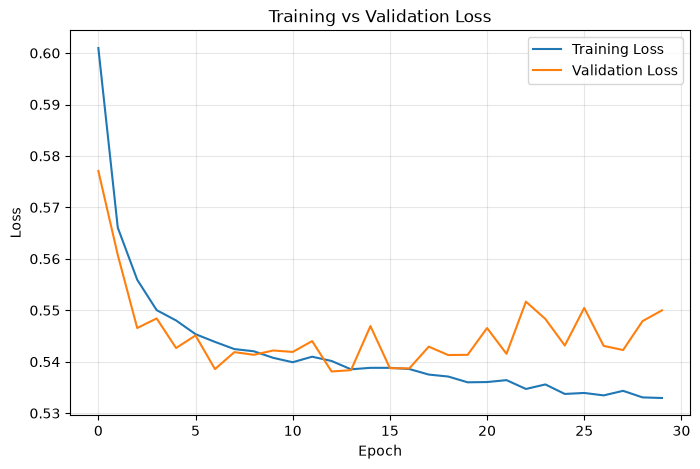

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

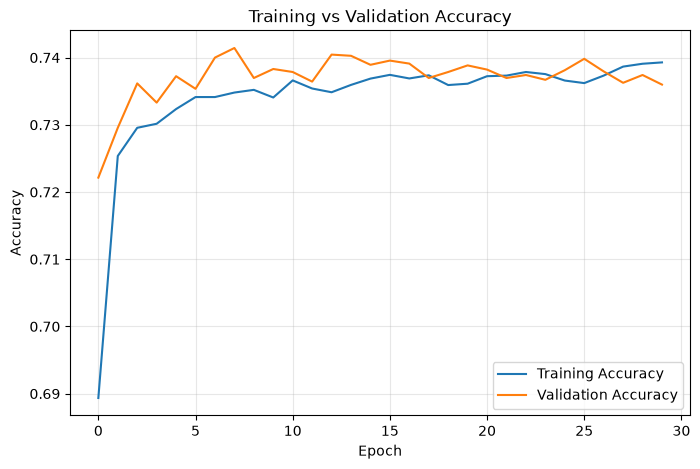

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

<div style="
    width:100%;
    box-sizing:border-box;
    background:
        radial-gradient(circle at 92% 8%,rgba(16,185,129,0.07),transparent 24%),
        radial-gradient(circle at 8% 92%,rgba(20,184,166,0.05),transparent 28%),
        linear-gradient(135deg,#F7FCFA 0%,#FFFFFF 50%,#F1FAF7 100%);
    padding:28px 34px;
    border-radius:24px;
    font-family:'Segoe UI',Arial,sans-serif;
    border:1px solid #B8DACE;
    box-shadow:0 10px 28px rgba(6,78,59,0.08);
    overflow:hidden;
">

<div style="
    color:#115E59;
    font-size:9px;
    font-weight:900;
    letter-spacing:2px;
    margin-bottom:7px;
">
FIT DIAGNOSIS
</div>

<div style="
    color:#0B2923;
    font-size:21px;
    font-weight:900;
    margin-bottom:18px;
">
What Do the Curves Tell Us?
</div>


<div style="
    display:grid;
    grid-template-columns:minmax(0,1fr) minmax(0,1fr);
    gap:14px;
    width:100%;
    box-sizing:border-box;
">


<!-- LEARNING -->

<div style="
    width:100%;
    min-width:0;
    box-sizing:border-box;
    background:#F1F9F6;
    border:1px solid #C1DED2;
    border-left:4px solid #10B981;
    border-radius:16px;
    padding:17px;
">

<div style="
    color:#065F46;
    font-size:9px;
    font-weight:900;
    letter-spacing:1.4px;
">
LEARNING
</div>

<div style="
    color:#14532D;
    font-size:16px;
    font-weight:900;
    margin-top:7px;
">
The Model Learns
</div>

<div style="
    color:#475569;
    font-size:10px;
    line-height:1.75;
    font-weight:600;
    margin-top:7px;
">
Training accuracy increased from
<span style="color:#047857;font-weight:900;">68.94%</span>
to
<span style="color:#047857;font-weight:900;">73.93%</span>,
while training loss generally decreased.
</div>

</div>


<!-- VALIDATION -->

<div style="
    width:100%;
    min-width:0;
    box-sizing:border-box;
    background:#EAF9F7;
    border:1px solid #99D4CB;
    border-radius:16px;
    padding:17px;
">

<div style="
    color:#0F766E;
    font-size:9px;
    font-weight:900;
    letter-spacing:1.4px;
">
VALIDATION
</div>

<div style="
    color:#134E4A;
    font-size:16px;
    font-weight:900;
    margin-top:7px;
">
Performance Stabilizes
</div>

<div style="
    color:#475569;
    font-size:10px;
    line-height:1.75;
    font-weight:600;
    margin-top:7px;
">
Validation accuracy reached about
<span style="color:#0F766E;font-weight:900;">74.14%</span>
at Epoch 8 and then remained around
<span style="color:#0F766E;font-weight:900;">73–74%</span>.
</div>

</div>

</div>


<!-- OVERFITTING -->

<div style="
    margin-top:15px;
    padding:15px 17px;
    background:#F8FBF9;
    border:1px solid #C8DED6;
    border-radius:15px;
    box-sizing:border-box;
">

<div style="
    color:#115E59;
    font-size:9px;
    font-weight:900;
    letter-spacing:1.5px;
    margin-bottom:7px;
">
OVERFITTING CHECK
</div>

<div style="
    color:#475569;
    font-size:10px;
    line-height:1.75;
    font-weight:600;
">
There is no severe overfitting. Training and validation accuracy stay relatively close,
although the validation loss begins to fluctuate after the earlier epochs.
This suggests that the model reaches a fairly stable level of generalization.
</div>

</div>


<!-- BEST OBSERVATION -->

<div style="
    margin-top:15px;
    padding:15px 18px;
    background:#EDF9F1;
    border:1px solid #A9D2B7;
    border-radius:15px;
    text-align:center;
    box-sizing:border-box;
">

<span style="
    color:#166534;
    font-size:9px;
    font-weight:900;
    letter-spacing:1.3px;
">
OBSERVATION
</span>

<span style="
    color:#475569;
    font-size:10px;
    font-weight:600;
    margin-left:8px;
">
The model learns quickly during the first epochs, then performance becomes mostly stable.
</span>

<span style="
    color:#166534;
    font-size:10px;
    font-weight:900;
">
Further regularization can be tested to improve generalization.
</span>

</div>

</div>

<div style="
    width:100%;
    box-sizing:border-box;
    background:
        radial-gradient(circle at 92% 8%,rgba(16,185,129,0.07),transparent 24%),
        radial-gradient(circle at 8% 92%,rgba(20,184,166,0.05),transparent 28%),
        linear-gradient(135deg,#F7FCFA 0%,#FFFFFF 50%,#F1FAF7 100%);
    padding:28px 34px;
    border-radius:24px;
    font-family:'Segoe UI',Arial,sans-serif;
    border:1px solid #B8DACE;
    box-shadow:0 10px 28px rgba(6,78,59,0.08);
    overflow:hidden;
">

<div style="
    color:#115E59;
    font-size:9px;
    font-weight:900;
    letter-spacing:2px;
    margin-bottom:7px;
">
STEP 04
</div>

<div style="
    color:#0B2923;
    font-size:21px;
    font-weight:900;
    margin-bottom:8px;
">
Add Dropout and Compare
</div>

<div style="
    color:#52665F;
    font-size:11px;
    line-height:1.7;
    font-weight:600;
">
Add dropout layers to regularize the network, retrain it with the same training setup,
and compare the new validation loss with the baseline model.
</div>

<div style="
    margin-top:15px;
    padding:13px 16px;
    background:#F1F9F6;
    border:1px solid #C1DED2;
    border-left:4px solid #10B981;
    border-radius:13px;
    text-align:center;
">

<span style="
    color:#065F46;
    font-size:9px;
    font-weight:900;
    letter-spacing:1.2px;
">
GOAL
</span>

<span style="
    color:#475569;
    font-size:10px;
    font-weight:600;
    margin-left:8px;
">
Reduce overfitting and improve generalization.
</span>

</div>

</div>

In [ ]:
# Build an improved model with dropout
improved_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.30),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(1, activation="sigmoid")
])

improved_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

improved_history = improved_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

Epoch 1/30
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.6560 - loss: 0.6234 - val_accuracy: 0.7064 - val_loss: 0.5882
Epoch 2/30
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7093 - loss: 0.5844 - val_accuracy: 0.7339 - val_loss: 0.5577
Epoch 3/30
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7227 - loss: 0.5662 - val_accuracy: 0.7334 - val_loss: 0.5448
Epoch 4/30
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7252 - loss: 0.5594 - val_accuracy: 0.7373 - val_loss: 0.5420
Epoch 5/30
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7273 - loss: 0.5554 - val_accuracy: 0.7393 - val_loss: 0.5445
Epoch 6/30
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7296 - loss: 0.5530 - val_accuracy: 0.7367 - val_loss: 0.5425
Epoch 7/30
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7306 - loss: 0.5526 - val_accuracy: 0.7387 - val_loss: 0.5419
Epoch 8/30
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7297 - loss: 0.5517 

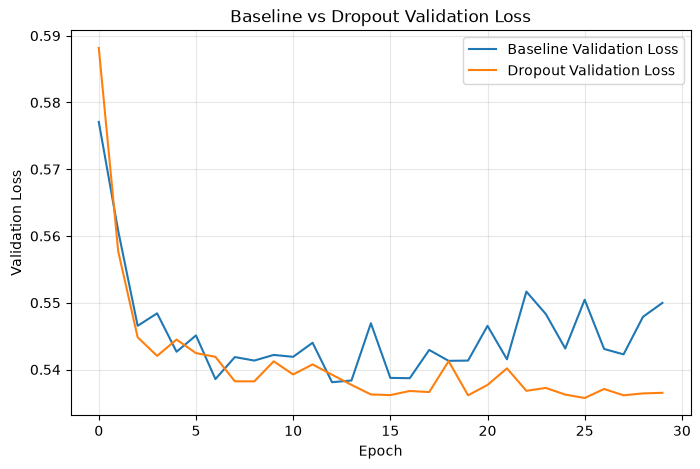

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["val_loss"],
    label="Baseline Validation Loss"
)

plt.plot(
    improved_history.history["val_loss"],
    label="Dropout Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Baseline vs Dropout Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

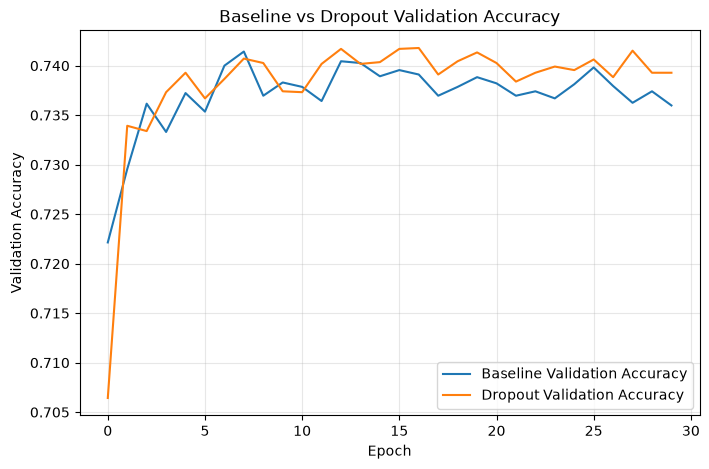

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["val_accuracy"],
    label="Baseline Validation Accuracy"
)

plt.plot(
    improved_history.history["val_accuracy"],
    label="Dropout Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Baseline vs Dropout Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

<div style="
    width:100%;
    box-sizing:border-box;
    background:#F8FBF9;
    padding:18px 20px;
    border-radius:17px;
    font-family:'Segoe UI',Arial,sans-serif;
    border:1px solid #C8DED6;
">

<div style="
    color:#115E59;
    font-size:9px;
    font-weight:900;
    letter-spacing:1.5px;
">
COMPARISON
</div>

<div style="
    color:#0B2923;
    font-size:18px;
    font-weight:900;
    margin-top:6px;
">
Baseline vs Dropout
</div>

<div style="
    color:#475569;
    font-size:10px;
    line-height:1.8;
    margin-top:8px;
">
The dropout model was compared with the baseline using validation loss and validation accuracy.
The better model is the one that provides lower validation loss and more stable validation performance.
</div>

</div>

<div style="
    width:100%;
    box-sizing:border-box;
    background:
        radial-gradient(circle at 92% 8%,rgba(16,185,129,0.07),transparent 24%),
        radial-gradient(circle at 8% 92%,rgba(20,184,166,0.05),transparent 28%),
        linear-gradient(135deg,#F7FCFA 0%,#FFFFFF 50%,#F1FAF7 100%);
    padding:28px 34px;
    border-radius:24px;
    font-family:'Segoe UI',Arial,sans-serif;
    border:1px solid #B8DACE;
    box-shadow:0 10px 28px rgba(6,78,59,0.08);
    overflow:hidden;
">

<div style="
    color:#166534;
    font-size:9px;
    font-weight:900;
    letter-spacing:2px;
    margin-bottom:7px;
">
STEP 05
</div>

<div style="
    color:#0B2923;
    font-size:21px;
    font-weight:900;
    margin-bottom:8px;
">
Evaluate the Final Model
</div>

<div style="
    color:#52665F;
    font-size:11px;
    line-height:1.7;
    font-weight:600;
">
Evaluate the improved neural network on the unseen test set and compare its performance
with the baseline model from Day 1.
</div>

<div style="
    margin-top:15px;
    padding:13px 16px;
    background:#EDF9F1;
    border:1px solid #A9D2B7;
    border-radius:13px;
    text-align:center;
">

<span style="
    color:#166534;
    font-size:9px;
    font-weight:900;
    letter-spacing:1.2px;
">
FINAL CHECK
</span>

<span style="
    color:#475569;
    font-size:10px;
    font-weight:600;
    margin-left:8px;
">
Test performance should be measured on data the model has never seen during training.
</span>

</div>

</div>

In [ ]:
test_loss, test_accuracy = improved_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4%}")

Test Loss: 0.5464
Test Accuracy: 73.1857%


In [ ]:
day1_baseline_accuracy = 0.5978

print(f"Day 1 Baseline Accuracy: {day1_baseline_accuracy:.2%}")
print(f"Neural Network Test Accuracy: {test_accuracy:.2%}")

improvement = test_accuracy - day1_baseline_accuracy

print(f"Improvement: {improvement:+.2%}")

Day 1 Baseline Accuracy: 59.78%
Neural Network Test Accuracy: 73.19%
Improvement: +13.41%


<div style="width:100%;box-sizing:border-box;background:linear-gradient(135deg,#F7FCFA 0%,#FFFFFF 52%,#F1FAF7 100%);padding:26px 32px;border-radius:24px;font-family:'Segoe UI',Arial,sans-serif;border:1px solid #B8DACE;box-shadow:0 10px 28px rgba(6,78,59,0.08);overflow:hidden;">

<div style="color:#047857;font-size:9px;font-weight:900;letter-spacing:2px;margin-bottom:7px;">FINAL RESULT</div>

<div style="color:#0B2923;font-size:21px;font-weight:900;line-height:1.25;margin-bottom:20px;">Neural Network vs Day 1 Baseline</div>

<div style="display:grid;grid-template-columns:minmax(0,1fr) minmax(0,1fr) minmax(0,1fr);gap:16px;width:100%;box-sizing:border-box;">

<div style="width:100%;box-sizing:border-box;background:#F8FBF9;border:1px solid #C8DED6;border-radius:15px;padding:16px 12px;text-align:center;">
<div style="color:#64748B;font-size:9px;font-weight:900;letter-spacing:1.2px;">DAY 1 BASELINE</div>
<div style="color:#334155;font-size:22px;font-weight:900;margin-top:8px;">59.78%</div>
</div>

<div style="width:100%;box-sizing:border-box;background:#E8F8F1;border:1px solid #98D0B9;border-radius:15px;padding:16px 12px;text-align:center;">
<div style="color:#047857;font-size:9px;font-weight:900;letter-spacing:1.2px;">NEURAL NETWORK</div>
<div style="color:#14532D;font-size:22px;font-weight:900;margin-top:8px;">73.19%</div>
</div>

<div style="width:100%;box-sizing:border-box;background:#EDF9F1;border:1px solid #A9D2B7;border-radius:15px;padding:16px 12px;text-align:center;">
<div style="color:#166534;font-size:9px;font-weight:900;letter-spacing:1.2px;">IMPROVEMENT</div>
<div style="color:#166534;font-size:22px;font-weight:900;margin-top:8px;">+13.41 pp</div>
</div>

</div>

<div style="width:100%;box-sizing:border-box;margin-top:18px;padding:15px 18px;background:#F1F9F6;border:1px solid #C1DED2;border-left:4px solid #10B981;border-radius:14px;text-align:center;">

<div style="color:#475569;font-size:11px;line-height:1.8;font-weight:600;">
The neural network achieved
<span style="color:#047857;font-weight:900;">73.19% test accuracy</span>,
which is
<span style="color:#166534;font-weight:900;">13.41 percentage points higher</span>
than the Day 1 baseline of 59.78%.
</div>

</div>

</div>